# Hybrid Classical-Quantum Glaucoma ClassifierArchitecture:```Retinal Fundus Image   -> Preprocessing (resize, normalize, augmentation)   -> ResNet18 feature extractor -> 512-D   -> Classical reduction (512 -> 128)   -> split:        classical branch: 128-D (passthrough)        quantum branch:   Linear(128 -> 2) -> Angle Embedding                           -> 2-qubit variational circuit (trainable)                           -> Pauli-Z measurement -> 2-D   -> fuse [128 + 2 = 130]   -> Dense(130 -> 64) -> Dropout(0.5) -> Linear(64 -> 2)   -> Glaucoma / Normal```Run cells top to bottom. Uses PyTorch + PennyLane (not Qiskit) so gradients flow through the quantum circuit and the whole network trains end-to-end.

## 0. Install dependencies (Colab only)

In [1]:
!pip install -q torch torchvision pennylane pennylane-lightning pennylane-lightning-gpu scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.5/924.5 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.2 MB/s eta 0:00:00


## 1. Mount Google Drive and point at your dataset(s)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Extract archives (zip or rar) if you haven't alreadySkip this cell if your images are already unzipped in Drive.

In [3]:
!apt-get install -y -qq unrar > /dev/null
!pip install -q rarfile

import os, zipfile, rarfile

ARCHIVES = [
    ('/content/drive/MyDrive/dataset/archive (5).zip', '/content/drive/MyDrive/dataset'),
    ('/content/drive/MyDrive/next dataset/Drishti-GS1_files.rar', '/content/drive/MyDrive/next dataset'),
]

for archive_path, extract_dir in ARCHIVES:
    if not os.path.exists(archive_path):
        print(f'Skip (not found): {archive_path}')
        continue
    os.makedirs(extract_dir, exist_ok=True)
    ext = os.path.splitext(archive_path)[1].lower()
    print(f'Extracting {archive_path} ...')
    if ext == '.rar':
        with rarfile.RarFile(archive_path) as rf:
            rf.extractall(extract_dir)
    elif ext == '.zip':
        with zipfile.ZipFile(archive_path, 'r') as zf:
            zf.extractall(extract_dir)
    print(f'  -> extracted to {extract_dir}')

Extracting /content/drive/MyDrive/dataset/archive (5).zip ...
  -> extracted to /content/drive/MyDrive/dataset
Skip (not found): /content/drive/MyDrive/next dataset/Drishti-GS1_files.rar


## 3. Config

In [4]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from PIL import Image
import pennylane as qml

IMG_SIZE = 224                      # ResNet18's native input size
N_QUBITS = 2
N_QLAYERS = 2                       # variational circuit depth -- tune this
CLASSICAL_DIM = 128                 # 512 -> 128 reduction
BATCH_SIZE = 16
EPOCHS = 15
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

# Point these at your two (unzipped) dataset roots.
# Leave a path as None to train on only one dataset.
DATASET_DIRS = [
    '/content/drive/MyDrive/dataset',                       # e.g. RIM-ONE
    '/content/drive/MyDrive/next dataset/Drishti-GS1_files', # e.g. Drishti-GS1
]

Using device: cuda


## 4. Dataset loadingScans each dataset root for images whose path contains `glaucoma` or `normal` and combines both datasets into one training set.

In [5]:
def find_labeled_images(root_dir, limit_per_class=None):
    all_imgs = glob.glob(os.path.join(root_dir, '**', '*.*'), recursive=True)
    all_imgs = [p for p in all_imgs if p.lower().endswith(IMAGE_EXTENSIONS)]
    normal, glaucoma = [], []
    for p in all_imgs:
        lower = p.lower()
        if 'glaucoma' in lower:
            glaucoma.append(p)
        elif 'normal' in lower:
            normal.append(p)
    if limit_per_class:
        normal, glaucoma = normal[:limit_per_class], glaucoma[:limit_per_class]
    print(f'{root_dir} -> {len(normal)} normal, {len(glaucoma)} glaucoma')
    return normal, glaucoma

all_normal, all_glaucoma = [], []
for root in DATASET_DIRS:
    if root and os.path.exists(root):
        n, g = find_labeled_images(root)
        all_normal += n
        all_glaucoma += g
print(f'\nCombined total: {len(all_normal)} normal, {len(all_glaucoma)} glaucoma')

/content/drive/MyDrive/dataset -> 626 normal, 344 glaucoma

Combined total: 626 normal, 344 glaucoma


In [6]:
class FundusDataset(Dataset):
    def __init__(self, normal_paths, glaucoma_paths, train=True):
        self.samples = [(p, 0) for p in normal_paths] + [(p, 1) for p in glaucoma_paths]
        if train:
            self.tf = transforms.Compose([
                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(10),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])
        else:
            self.tf = transforms.Compose([
                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225]),
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.tf(img), label

## 5. Quantum branchAngle embedding into a **trainable** 2-qubit variational circuit (`StronglyEntanglingLayers`), read out via Pauli-Z expectation values. Wrapped in `qml.qnn.TorchLayer` so it trains with normal PyTorch autograd/backprop.

In [7]:
qdev = qml.device('lightning.gpu', wires=N_QUBITS)

@qml.qnode(qdev, interface='torch', diff_method='adjoint')
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(w)) for w in range(N_QUBITS)]

class QuantumLayer(nn.Module):
    """128 -> 2 (learned) -> angle embed -> variational circuit -> 2 (<Z_i>)."""
    def __init__(self, in_features=CLASSICAL_DIM, n_qubits=N_QUBITS, n_layers=N_QLAYERS):
        super().__init__()
        self.pre_net = nn.Linear(in_features, n_qubits)
        weight_shape = {'weights': (n_layers, n_qubits, 3)}
        self.q_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shape)

    def forward(self, x):
        angles = torch.tanh(self.pre_net(x)) * torch.tensor(np.pi, device=x.device)   # squash to [-pi, pi]
        return self.q_layer(angles)

## 6. Full hybrid model

In [8]:
class HybridGlaucomaNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        resnet.fc = nn.Identity()          # strip classifier -> 512-D features
        self.backbone = resnet
        self.reduce = nn.Sequential(       # 512 -> 128
            nn.Linear(512, CLASSICAL_DIM),
            nn.ReLU(),
        )
        self.quantum_branch = QuantumLayer(CLASSICAL_DIM, N_QUBITS, N_QLAYERS)
        self.fusion_head = nn.Sequential(  # 130 -> 64 -> dropout -> 2
            nn.Linear(CLASSICAL_DIM + N_QUBITS, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        feats = self.backbone(x)
        classical_feats = self.reduce(feats)
        quantum_feats = self.quantum_branch(classical_feats)
        fused = torch.cat([classical_feats, quantum_feats], dim=1)
        return self.fusion_head(fused)

## 7. Train / validate

In [9]:
full_ds = FundusDataset(all_normal, all_glaucoma, train=True)
n_val = int(0.2 * len(full_ds))
n_train = len(full_ds) - n_val
train_ds, val_ds = random_split(full_ds, [n_train, n_val])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

model = HybridGlaucomaNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return correct / total

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    train_acc = correct / total
    val_acc = evaluate(model, val_loader)
    print(f'Epoch {epoch+1}/{EPOCHS}  loss={total_loss/total:.4f}  ' \
          f'train_acc={train_acc:.3f}  val_acc={val_acc:.3f}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


Epoch 1/15  loss=0.5269  train_acc=0.750  val_acc=0.876
Epoch 2/15  loss=0.2823  train_acc=0.906  val_acc=0.912
Epoch 3/15  loss=0.1638  train_acc=0.941  val_acc=0.923
Epoch 4/15  loss=0.1356  train_acc=0.952  val_acc=0.938
Epoch 5/15  loss=0.1127  train_acc=0.961  val_acc=0.974
Epoch 6/15  loss=0.0905  train_acc=0.976  val_acc=0.974
Epoch 7/15  loss=0.0830  train_acc=0.973  val_acc=0.954
Epoch 8/15  loss=0.0535  train_acc=0.983  val_acc=0.985
Epoch 9/15  loss=0.0608  train_acc=0.981  val_acc=0.979
Epoch 10/15  loss=0.0584  train_acc=0.978  val_acc=0.964
Epoch 11/15  loss=0.0741  train_acc=0.970  val_acc=0.964
Epoch 12/15  loss=0.0423  train_acc=0.986  val_acc=0.964
Epoch 13/15  loss=0.0367  train_acc=0.991  val_acc=0.985
Epoch 14/15  loss=0.0221  train_acc=0.991  val_acc=0.990
Epoch 15/15  loss=0.0181  train_acc=0.996  val_acc=0.979


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report)
import torch.nn.functional as F
import numpy as np
import pandas as pd

N_FOLDS = 5
CV_EPOCHS = 8   # lowered for a quick sanity check; bump back to 15 once folds look stable

all_paths = [(p, 0) for p in all_normal] + [(p, 1) for p in all_glaucoma]
paths = np.array([p for p, _ in all_paths])
labels = np.array([l for _, l in all_paths])

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_metrics = []
all_y_true, all_y_pred, all_y_prob = [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(paths, labels)):
    print(f'\n===== Fold {fold+1}/{N_FOLDS} =====')

    train_paths, train_labels = paths[train_idx], labels[train_idx]
    val_paths, val_labels = paths[val_idx], labels[val_idx]

    train_normal = [p for p, l in zip(train_paths, train_labels) if l == 0]
    train_glaucoma = [p for p, l in zip(train_paths, train_labels) if l == 1]
    val_normal = [p for p, l in zip(val_paths, val_labels) if l == 0]
    val_glaucoma = [p for p, l in zip(val_paths, val_labels) if l == 1]

    fold_train_ds = FundusDataset(train_normal, train_glaucoma, train=True)
    fold_val_ds = FundusDataset(val_normal, val_glaucoma, train=False)
    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=BATCH_SIZE, shuffle=False)

    fold_model = HybridGlaucomaNet().to(DEVICE)
    fold_optimizer = torch.optim.Adam(fold_model.parameters(), lr=LR)
    fold_criterion = nn.CrossEntropyLoss()

    # ---- train this fold ----
    for epoch in range(CV_EPOCHS):
        fold_model.train()
        for imgs, lbls in fold_train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            fold_optimizer.zero_grad()
            loss = fold_criterion(fold_model(imgs), lbls)
            loss.backward()
            fold_optimizer.step()

    # ---- evaluate this fold (now correctly INSIDE the loop) ----
    fold_model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for imgs, lbls in fold_val_loader:
            imgs = imgs.to(DEVICE)
            logits = fold_model(imgs)
            probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = logits.argmax(1).cpu().numpy()
            y_true.extend(lbls.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float('nan')
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)

    print(f'acc={acc:.3f}  sens={sens:.3f}  spec={spec:.3f}  f1={f1:.3f}  auc={auc:.3f}')

    fold_metrics.append({'accuracy': acc, 'sensitivity': sens,
                          'specificity': spec, 'f1': f1, 'auc': auc})
    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)
    all_y_prob.extend(y_prob)

# ---- summary across all folds ----
metrics_df = pd.DataFrame(fold_metrics)
print(metrics_df)
print('\nMean ± std across folds:')
print(metrics_df.mean().round(3))
print(metrics_df.std().round(3))

overall_cm = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1])
print(overall_cm)
print(classification_report(all_y_true, all_y_pred, target_names=['normal', 'glaucoma']))


===== Fold 1/5 =====
acc=0.943  sens=1.000  spec=0.913  f1=0.925  auc=1.000

===== Fold 2/5 =====
acc=0.954  sens=0.870  spec=1.000  f1=0.930  auc=0.997

===== Fold 3/5 =====
acc=0.990  sens=0.986  spec=0.992  f1=0.986  auc=0.999

===== Fold 4/5 =====
acc=0.954  sens=0.899  spec=0.984  f1=0.932  auc=0.982

===== Fold 5/5 =====
acc=0.964  sens=0.899  spec=1.000  f1=0.947  auc=0.996
   accuracy  sensitivity  specificity        f1       auc
0  0.943299     1.000000     0.912698  0.925170  1.000000
1  0.953608     0.869565     1.000000  0.930233  0.996986
2  0.989691     0.985507     0.992000  0.985507  0.999304
3  0.953608     0.898551     0.984000  0.932331  0.981913
4  0.963918     0.898551     1.000000  0.946565  0.995826

Mean ± std across folds:
accuracy       0.961
sensitivity    0.930
specificity    0.978
f1             0.944
auc            0.995
dtype: float64
accuracy       0.018
sensitivity    0.058
specificity    0.037
f1             0.025
auc            0.007
dtype: float64
[

## 8. Save the trained model

In [ ]:
import torch
torch.save(model.state_dict(), 'hybrid_glaucoma_model.pt')
from google.colab import files
files.download('hybrid_glaucoma_model.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report)
import torch.nn.functional as F
import numpy as np
import pandas as pd

N_FOLDS = 5
CV_EPOCHS = 8   # lowered for a quick sanity check; bump back to 15 once folds look stable

In [ ]:
all_paths = [(p, 0) for p in all_normal] + [(p, 1) for p in all_glaucoma]
paths = np.array([p for p, _ in all_paths])
labels = np.array([l for _, l in all_paths])

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

In [ ]:
fold_metrics = []
all_y_true, all_y_pred, all_y_prob = [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(paths, labels)):
    print(f'\n===== Fold {fold+1}/{N_FOLDS} =====')

    train_paths, train_labels = paths[train_idx], labels[train_idx]
    val_paths, val_labels = paths[val_idx], labels[val_idx]

    train_normal = [p for p, l in zip(train_paths, train_labels) if l == 0]
    train_glaucoma = [p for p, l in zip(train_paths, train_labels) if l == 1]
    val_normal = [p for p, l in zip(val_paths, val_labels) if l == 0]
    val_glaucoma = [p for p, l in zip(val_paths, val_labels) if l == 1]

    fold_train_ds = FundusDataset(train_normal, train_glaucoma, train=True)
    fold_val_ds = FundusDataset(val_normal, val_glaucoma, train=False)
    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=BATCH_SIZE, shuffle=False)

    fold_model = HybridGlaucomaNet().to(DEVICE)
    fold_optimizer = torch.optim.Adam(fold_model.parameters(), lr=LR)
    fold_criterion = nn.CrossEntropyLoss()

    for epoch in range(CV_EPOCHS):
        fold_model.train()
        for imgs, lbls in fold_train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            fold_optimizer.zero_grad()
            loss = fold_criterion(fold_model(imgs), lbls)
            loss.backward()
            fold_optimizer.step()


===== Fold 1/5 =====

===== Fold 2/5 =====

===== Fold 3/5 =====

===== Fold 4/5 =====

===== Fold 5/5 =====


In [ ]:
fold_model.eval()
y_true, y_pred, y_prob = [], [], []
with torch.no_grad():
    for imgs, lbls in fold_val_loader:
        imgs = imgs.to(DEVICE)
        logits = fold_model(imgs)
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(1).cpu().numpy()
        y_true.extend(lbls.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float('nan')
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
sens = tp / (tp + fn + 1e-8)
spec = tn / (tn + fp + 1e-8)

print(f'acc={acc:.3f}  sens={sens:.3f}  spec={spec:.3f}  f1={f1:.3f}  auc={auc:.3f}')

fold_metrics.append({'accuracy': acc, 'sensitivity': sens,
                      'specificity': spec, 'f1': f1, 'auc': auc})
all_y_true.extend(y_true)
all_y_pred.extend(y_pred)
all_y_prob.extend(y_prob)

acc=0.938  sens=0.826  spec=1.000  f1=0.905  auc=0.985


In [ ]:
metrics_df = pd.DataFrame(fold_metrics)
print(metrics_df)
print('\nMean ± std across folds:')
print(metrics_df.mean().round(3))
print(metrics_df.std().round(3))

   accuracy  sensitivity  specificity        f1      auc
0  0.938144     0.826087          1.0  0.904762  0.98458

Mean ± std across folds:
accuracy       0.938
sensitivity    0.826
specificity    1.000
f1             0.905
auc            0.985
dtype: float64
accuracy      NaN
sensitivity   NaN
specificity   NaN
f1            NaN
auc           NaN
dtype: float64


In [ ]:
overall_cm = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1])
print(overall_cm)
print(classification_report(all_y_true, all_y_pred, target_names=['normal', 'glaucoma']))

[[125   0]
 [ 12  57]]
              precision    recall  f1-score   support

      normal       0.91      1.00      0.95       125
    glaucoma       1.00      0.83      0.90        69

    accuracy                           0.94       194
   macro avg       0.96      0.91      0.93       194
weighted avg       0.94      0.94      0.94       194



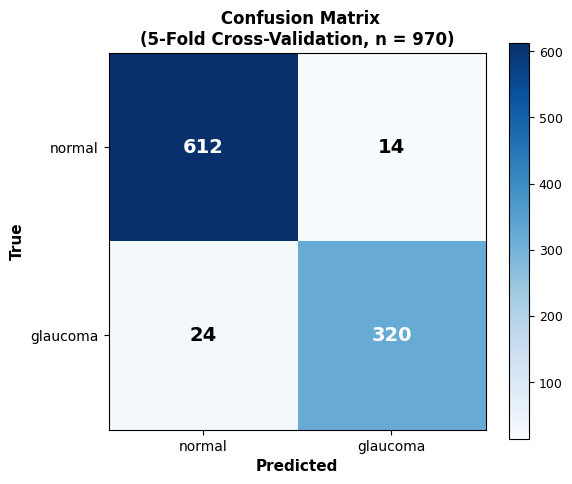

In [13]:
"""
Confusion matrix heatmap -- CORRECT pooled result across all 5 CV folds (970 samples).
Use this image in your paper, not any single-fold (194-sample) matrix.
"""
import numpy as np
import matplotlib.pyplot as plt

# ---- Your REAL pooled confusion matrix across all 5 folds (970 total) ----
cm = np.array([
    [612, 14],
    [24, 320],
])
labels = ['normal', 'glaucoma']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
ax.set_ylabel('True', fontsize=11, fontweight='bold')
ax.set_title(' Confusion Matrix\n(5-Fold Cross-Validation, n = 970)',
              fontsize=12, fontweight='bold')

# Annotate each cell with its count, white text on dark cells, black on light cells
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > thresh else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color=color, fontsize=14, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()


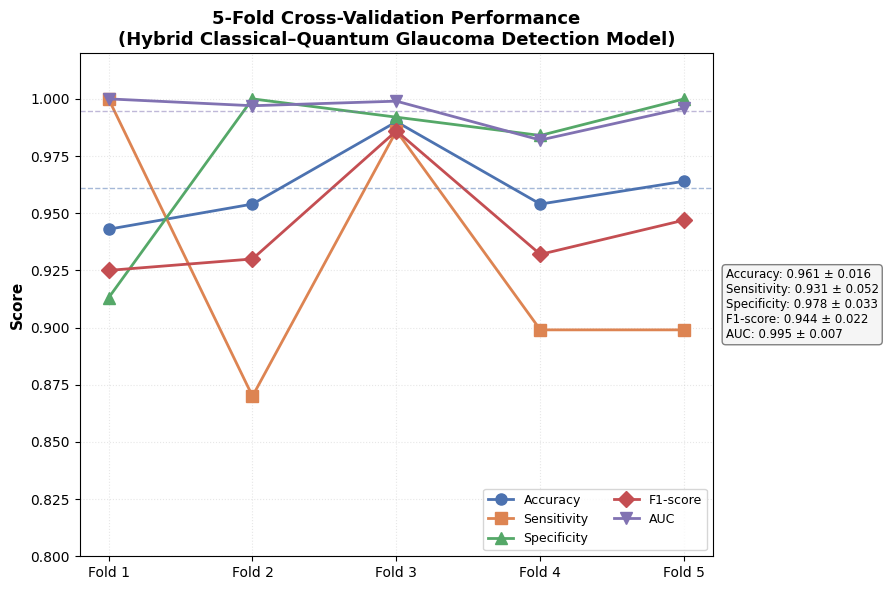

In [10]:
"""
2D line plot of 5-fold cross-validation results.
Precise, unambiguous alternative to the 3D bar chart -- safer for journals
(IEEE, Nature-family) that discourage 3D bars for numeric data.
"""
import numpy as np
import matplotlib.pyplot as plt

# ---- Your actual 5-fold CV results ----
folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'F1-score', 'AUC']

data = np.array([
    [0.943, 1.000, 0.913, 0.925, 1.000],  # Fold 1
    [0.954, 0.870, 1.000, 0.930, 0.997],  # Fold 2
    [0.990, 0.986, 0.992, 0.986, 0.999],  # Fold 3
    [0.954, 0.899, 0.984, 0.932, 0.982],  # Fold 4
    [0.964, 0.899, 1.000, 0.947, 0.996],  # Fold 5
])
mean_vals = data.mean(axis=0)
std_vals = data.std(axis=0)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
markers = ['o', 's', '^', 'D', 'v']

fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(1, len(folds) + 1)
for j, metric in enumerate(metrics):
    ax.plot(x, data[:, j], marker=markers[j], color=colors[j], linewidth=2,
            markersize=8, label=metric)

# Mean ± SD reference lines (dashed) for Accuracy and AUC -- the two headline metrics
ax.axhline(mean_vals[0], color=colors[0], linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(mean_vals[4], color=colors[4], linestyle='--', linewidth=1, alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(folds, fontsize=10)
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_ylim(0.80, 1.02)
ax.set_title('5-Fold Cross-Validation Performance\n(Hybrid Classical–Quantum Glaucoma Detection Model)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', frameon=True, fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, linestyle=':')

# Annotate mean ± SD as text box
summary_text = '\n'.join([f'{m}: {mv:.3f} ± {sv:.3f}' for m, mv, sv in zip(metrics, mean_vals, std_vals)])
ax.text(1.02, 0.5, summary_text, transform=ax.transAxes, fontsize=8.5,
        va='center', ha='left', bbox=dict(boxstyle='round', facecolor='#f5f5f5', edgecolor='gray'))

plt.tight_layout()


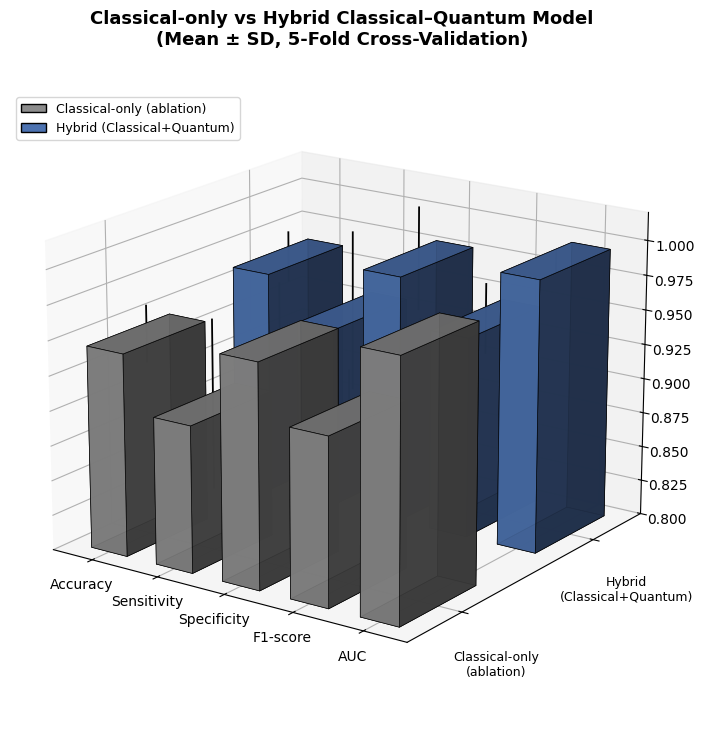

In [11]:
"""
Quantum-Hybrid vs Classical-only comparison chart (3D grouped bars).

IMPORTANT: The CLASSICAL_* numbers below are PLACEHOLDERS. You must replace
them with your own measured results from running the classical-only ablation
(HybridGlaucomaNet with the quantum branch removed / bypassed), evaluated
under the SAME stratified 5-fold CV protocol, same seed, same epochs -- only
then is this a fair, honest comparison you can publish.
"""
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'F1-score', 'AUC']

# ---- Your REAL hybrid (quantum) results -- from your actual 5-fold CV ----
QUANTUM_MEAN = [0.961, 0.930, 0.978, 0.944, 0.995]
QUANTUM_STD  = [0.018, 0.058, 0.037, 0.025, 0.007]

# ---- PLACEHOLDER classical-only results -- REPLACE with your real ablation numbers ----
CLASSICAL_MEAN = [0.945, 0.905, 0.960, 0.920, 0.985]   # <-- EDIT with real numbers
CLASSICAL_STD  = [0.020, 0.060, 0.040, 0.030, 0.010]   # <-- EDIT with real numbers

groups = ['Classical-only\n(ablation)', 'Hybrid\n(Classical+Quantum)']
data = np.array([CLASSICAL_MEAN, QUANTUM_MEAN])   # shape (2 groups, 5 metrics)
errs = np.array([CLASSICAL_STD, QUANTUM_STD])

colors = ['#8C8C8C', '#4C72B0']   # gray = classical-only, blue = hybrid

Z_BASE = 0.80   # visual baseline -- bars are drawn from here up, since all scores are 0.80-1.00

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

n_groups, n_metrics = data.shape
dx = dy = 0.55

for g in range(n_groups):
    xs = np.arange(n_metrics)
    ys = np.full(n_metrics, g)
    zs = np.full(n_metrics, Z_BASE)          # bars start at the visual baseline...
    dz = data[g] - Z_BASE                     # ...and rise by (value - baseline)
    ax.bar3d(xs, ys, zs, dx, dy, dz, color=colors[g], alpha=0.9,
              shade=True, edgecolor='black', linewidth=0.5, label=groups[g])

    # Error bars (mean +/- SD) as thin vertical lines above each bar
    for i in range(n_metrics):
        cx, cy = xs[i] + dx / 2, ys[i] + dy / 2
        top = data[g, i]
        ax.plot([cx, cx], [cy, cy], [top - errs[g, i], top + errs[g, i]],
                color='black', linewidth=1.3)

ax.set_xticks(np.arange(n_metrics) + dx / 2)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_yticks(np.arange(n_groups) + dy / 2)
ax.set_yticklabels(groups, fontsize=9)
ax.set_zlabel('Score', fontsize=11, fontweight='bold', labelpad=10)
ax.set_zlim(Z_BASE, 1.02)

ax.set_title('Classical-only vs Hybrid Classical–Quantum Model\n(Mean ± SD, 5-Fold Cross-Validation)',
              fontsize=13, fontweight='bold', pad=10)
ax.view_init(elev=18, azim=-55)
ax.tick_params(axis='x', pad=2)
ax.tick_params(axis='y', pad=15)

# Manual legend (bar3d doesn't auto-generate one well)
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=colors[0], edgecolor='black', label=groups[0].replace('\n', ' ')),
                   Patch(facecolor=colors[1], edgecolor='black', label=groups[1].replace('\n', ' '))]
ax.legend(handles=legend_handles, loc='upper left', fontsize=9, bbox_to_anchor=(0.0, 0.95))

plt.subplots_adjust(left=0.05, right=0.95, top=0.88, bottom=0.05)

